In [108]:
import numpy as np
import matplotlib.pyplot as plt

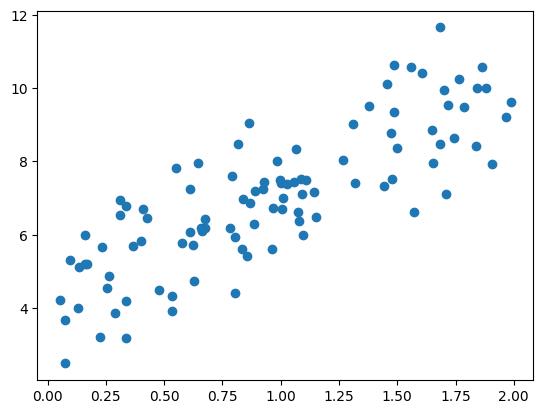

In [109]:
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)
plt.scatter(X,y)
plt.show()

In [110]:
X_b = np.c_[np.ones((100,1)),X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [111]:
theta_best

array([[4.24468389],
       [2.89849618]])

In [112]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)),X_new]
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 4.24468389],
       [10.04167625]])

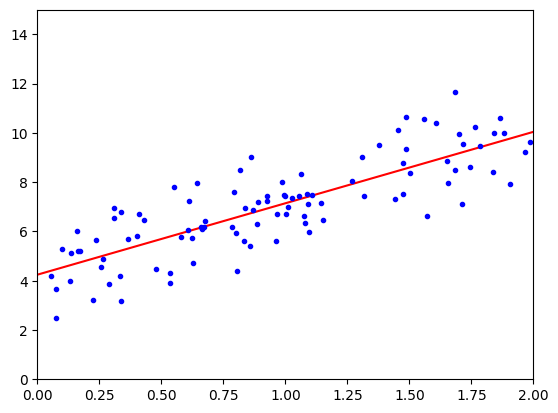

In [113]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [114]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
lin_reg.intercept_, lin_reg.coef_


(array([4.24468389]), array([[2.89849618]]))

In [115]:
lin_reg.predict(X_new)

array([[ 4.24468389],
       [10.04167625]])

In [116]:
theta_best_svd, residuals, ranks, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.24468389],
       [2.89849618]])

<h3>Batch Gradient Descent
</h3>

In [118]:
alpha = 0.1
n_iterations = 1000 
m = 1000 # no of training examples 

theta = np.random.randn(2,1) 

for iteration in range(n_iterations):
    gradient = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - alpha * gradient#to get the new theta value

In [119]:
theta
#to find a good learning rate use grid search
#set no of iteration large and interrupt when gradient become tiny 
#when gradient reaches at minimum at 

array([[4.1361793 ],
       [2.99574797]])

<h3>stochastic Gradient Descent </h3>

- major problem is Batch Gradient descent uses whole trainig set at every step
- has good accuracy but it is high memory based and intensiv

<h4>how stochastic gradient descent work</h4>

- it simply pick random instance on training set and calculate gradient at that point
- it run faster on single instances
- on that case it can work on huge datasets
- here gradeints are random and cost function dereasing  average
- once it will reach global minima it will not settle and keep bouncing here and there
- it escape local minima early but never settle on global minina for that `decrese learning rate over time `
- one more thing is we can suffle the input featuers

In [123]:
n_epochs = 50

t0, t1 = 5, 50 

def learning_rate(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index : random_index+1]
        gradient = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_rate(epoch * m +i)
        theta = theta - eta * gradient

In [124]:
theta

array([[4.16660821],
       [2.95942946]])

In [125]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter = 1000, tol = 1e-3, penalty = None, eta0 = 0.1)
sgd_reg.fit(X, y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [126]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21825972]), array([2.92715799]))

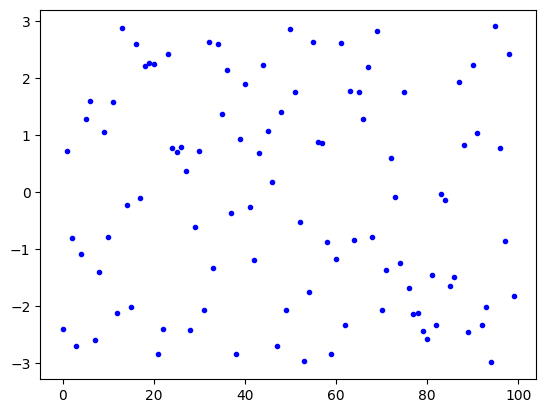

In [127]:
m = 100
X = 6 * np.random.rand(m,1) - 3

plt.plot(X,'b.')

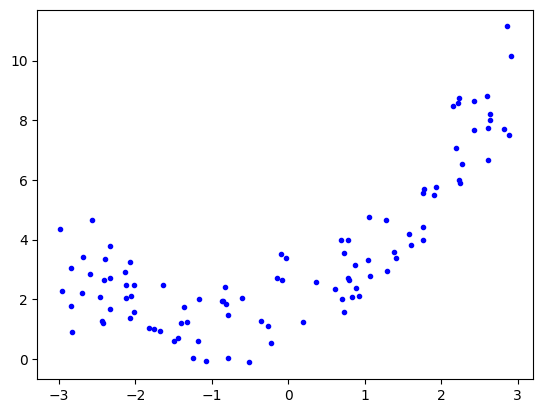

In [128]:
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m,1)
plt.plot(X, y, 'b.')

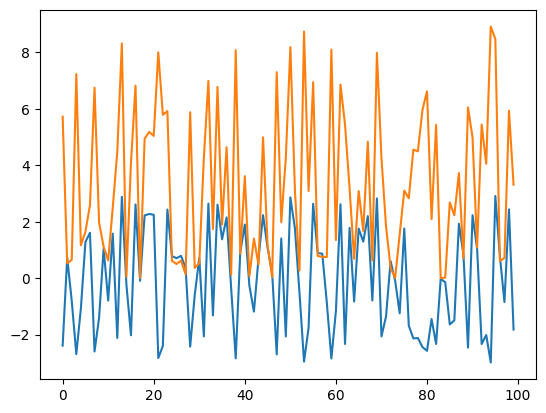

In [129]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
plt.plot(X_poly)

In [130]:
#X_poly contain origianl features of X + squared one 
#so now fit linear features of X
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_
#bias, theta1(X), theta2(X^2)

(array([1.76586965]), array([[1.04978646, 0.53060499]]))

In [175]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)
    train_errors, val_errors = [], [] #creating list to store error
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))

    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")

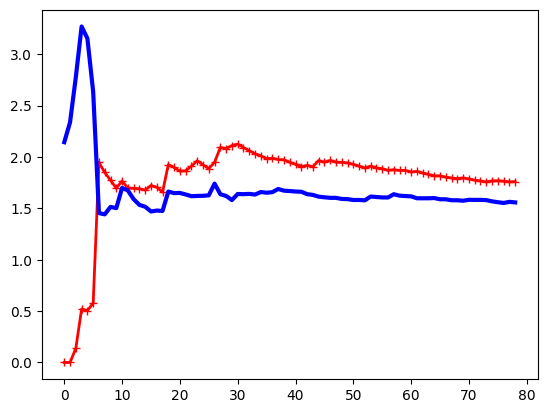

In [177]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

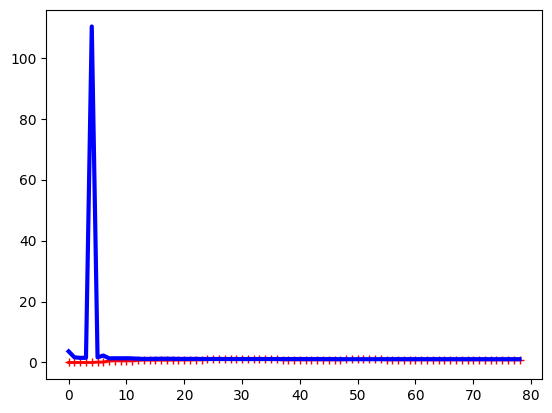

In [179]:
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
    ("poly_features", PolynomialFeatures(degree=4, include_bias = False)),
    ("lin_Reg", LinearRegression()),
])
plot_learning_curves(polynomial_regression, X, y)

In [181]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha = 1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([5.04484755])

In [183]:
sdg_reg = SGDRegressor(penalty="l2")# l1 is lasso , l2 is ridge 
sdg_reg.fit(X, y.ravel())
sdg_reg.predict([[1.5]])

array([5.03589269])

In [185]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha = 0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([5.00247366])

In [187]:
#Elastic Net
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha = 0.1, l1_ratio = 0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([5.00330905])

In [205]:

#Implemetation of early stopping 
"""
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)
#prepare the data 
poly_scaler = Pipeline([
    ('poly_features' , PolynomialFeatures(degree = 90, include_bias = False)),
    ('std_scaler' , StandardScaler())
])

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

sdg_reg = SGDRegressor(max_iter = 1,  warm_start = True,
                       penalty=None, learning_rate = "constant", eta0 = 0.0005)


minimum_val_error = float("inf")
best_epoch = None
best_model = None
for epoch in range(1000):
    sdg_reg.fit(X_train_poly_scaled, y_train)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_perdict)
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_model = clone(sgd_reg)
        """

'\nfrom sklearn.base import clone\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.model_selection import train_test_split\n\nX_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)\n#prepare the data \npoly_scaler = Pipeline([\n    (\'poly_features\' , PolynomialFeatures(degree = 90, include_bias = False)),\n    (\'std_scaler\' , StandardScaler())\n])\n\nX_train_poly_scaled = poly_scaler.fit_transform(X_train)\nX_val_poly_scaled = poly_scaler.transform(X_val)\n\nsdg_reg = SGDRegressor(max_iter = 1,  warm_start = True,\n                       penalty=None, learning_rate = "constant", eta0 = 0.0005)\n\n\nminimum_val_error = float("inf")\nbest_epoch = None\nbest_model = None\nfor epoch in range(1000):\n    sdg_reg.fit(X_train_poly_scaled, y_train)\n    y_val_predict = sgd_reg.predict(X_val_poly_scaled)\n    val_error = mean_squared_error(y_val, y_val_perdict)\n    if val_error < minimum_val_error:\n        minimum_val_error = val_error\n        best_epoch 

In [207]:
from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [217]:
import numpy as np
X = iris['data'][:,3:]# all rows and columns after three
y = (iris['target' ] == 2).astype(int)

In [223]:
#Import logistic regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


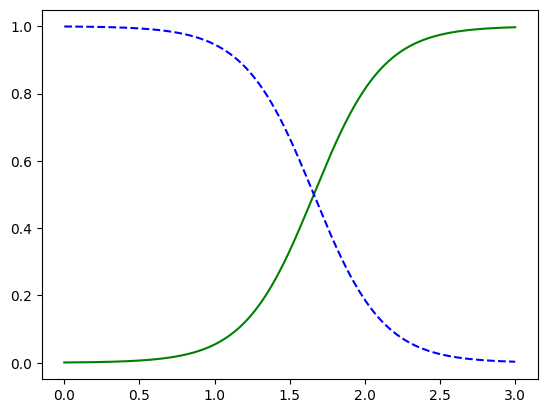

In [237]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris virginica")
plt.show()
#at interceptions thats decision boundary


In [241]:
log_reg.predict([[1.7], [1.5]])

array([1, 0])

<h3>Softmax Regression </h3>

- Multinomial Regression use to select multiple classes
- one vs all and one vs one 

In [246]:
X = iris['data'][:,(2,3)]
y = iris['target']

softmax_reg = LogisticRegression(multi_class = "multinomial" , solver= "lbfgs", C = 10)
softmax_reg.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [250]:
softmax_reg.predict([[5,2]])

array([2])

In [252]:
softmax_reg.predict_proba([[5,2]])

array([[6.21626372e-07, 5.73689802e-02, 9.42630398e-01]])